In [2]:
import pandas as pd
import numpy as np

pd.set_option('max_colwidth', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 8)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from ipywidgets import interact

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
data=pd.read_csv('Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='N', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Nitrogen')

<Axes: >

<Axes: xlabel='P', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Phosphorous')

<Axes: >

<Axes: xlabel='K', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Potassium')

<Axes: >

<Axes: xlabel='temperature', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Temperature')

<Axes: >

<Axes: xlabel='humidity', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Humidity')

<Axes: >

<Axes: xlabel='ph', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of PH')

<Axes: >

<Axes: xlabel='rainfall', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Rainfall')

Text(0.5, 0.98, 'Distribution of agricultural conditions')

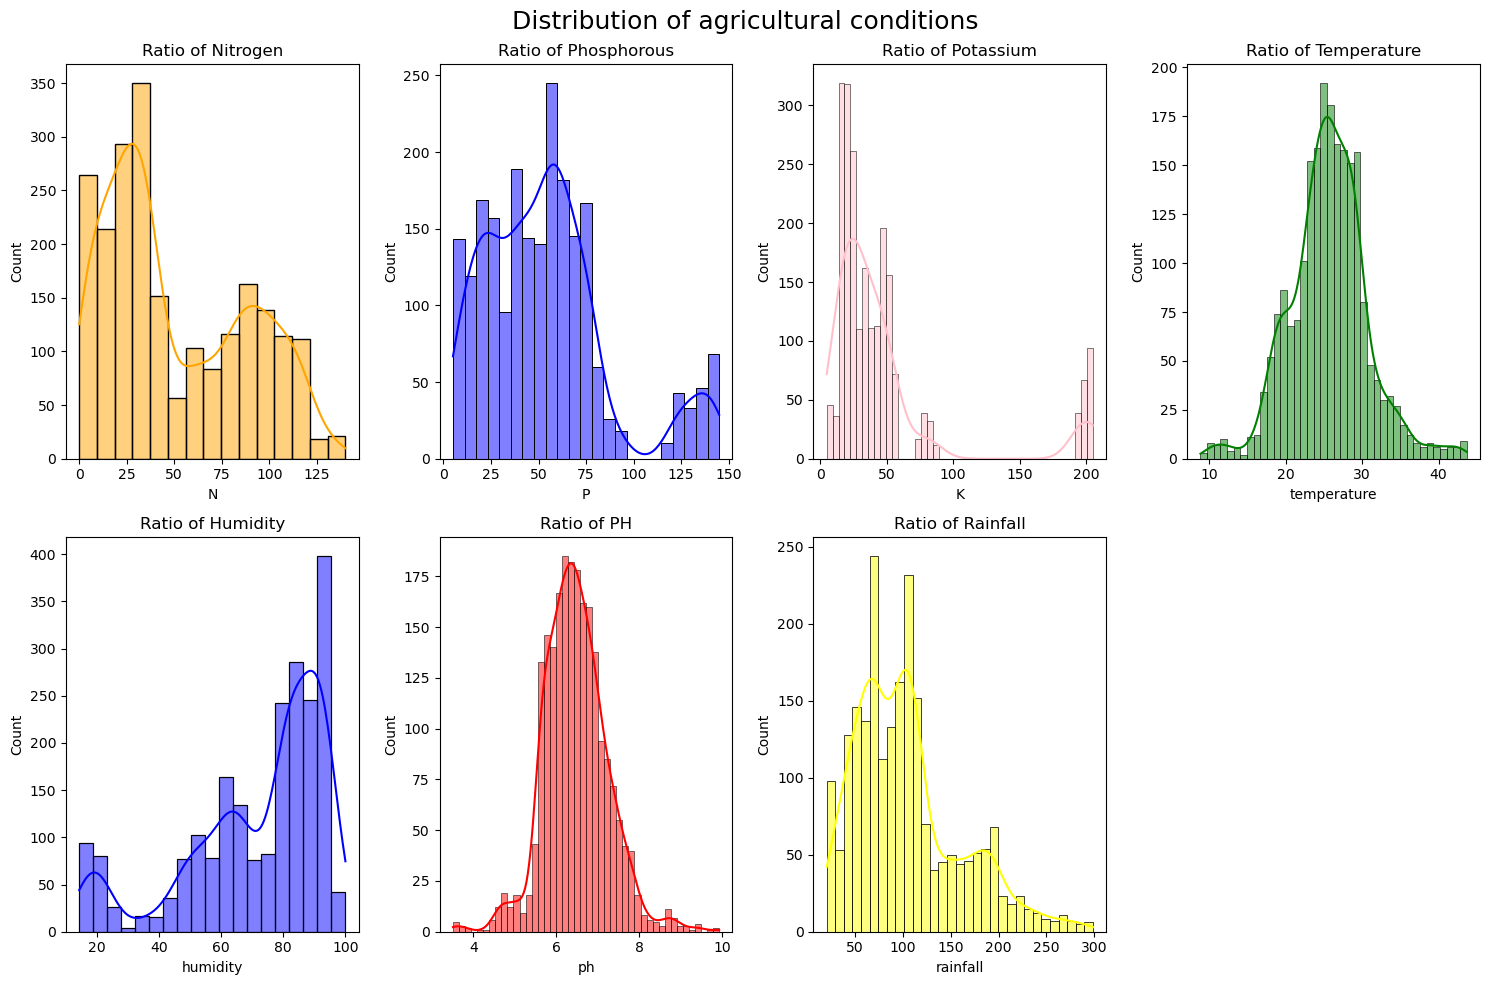

In [4]:
plt.figure(figsize=(15,10))

plt.subplot(2,4,1)
sns.histplot(data['N'], kde=True, color='orange')
plt.title("Ratio of Nitrogen")

plt.subplot(2,4,2)
sns.histplot(data['P'], kde=True, color='blue')
plt.title("Ratio of Phosphorous")

plt.subplot(2,4,3)
sns.histplot(data['K'], kde=True, color='pink')
plt.title("Ratio of Potassium")

plt.subplot(2,4,4)
sns.histplot(data['temperature'], kde=True, color='green')
plt.title("Ratio of Temperature")
plt.subplot(2,4,5)
sns.histplot(data['humidity'], kde=True, color='blue')
plt.title("Ratio of Humidity")

plt.subplot(2,4,6)
sns.histplot(data['ph'], kde=True, color='red')
plt.title("Ratio of PH")

plt.subplot(2,4,7)
sns.histplot(data['rainfall'], kde=True, color='yellow')
plt.title("Ratio of Rainfall")

plt.suptitle("Distribution of agricultural conditions", fontsize=18)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='N', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Nitrogen')

<Axes: >

<Axes: xlabel='P', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Phosphorous')

<Axes: >

<Axes: xlabel='K', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Potassium')

<Axes: >

<Axes: xlabel='temperature', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Temperature')

<Axes: >

<Axes: xlabel='humidity', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Humidity')

<Axes: >

<Axes: xlabel='ph', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of PH')

<Axes: >

<Axes: xlabel='rainfall', ylabel='Count'>

Text(0.5, 1.0, 'Ratio of Rainfall')

Text(0.5, 0.98, 'Distribution of agricultural conditions')

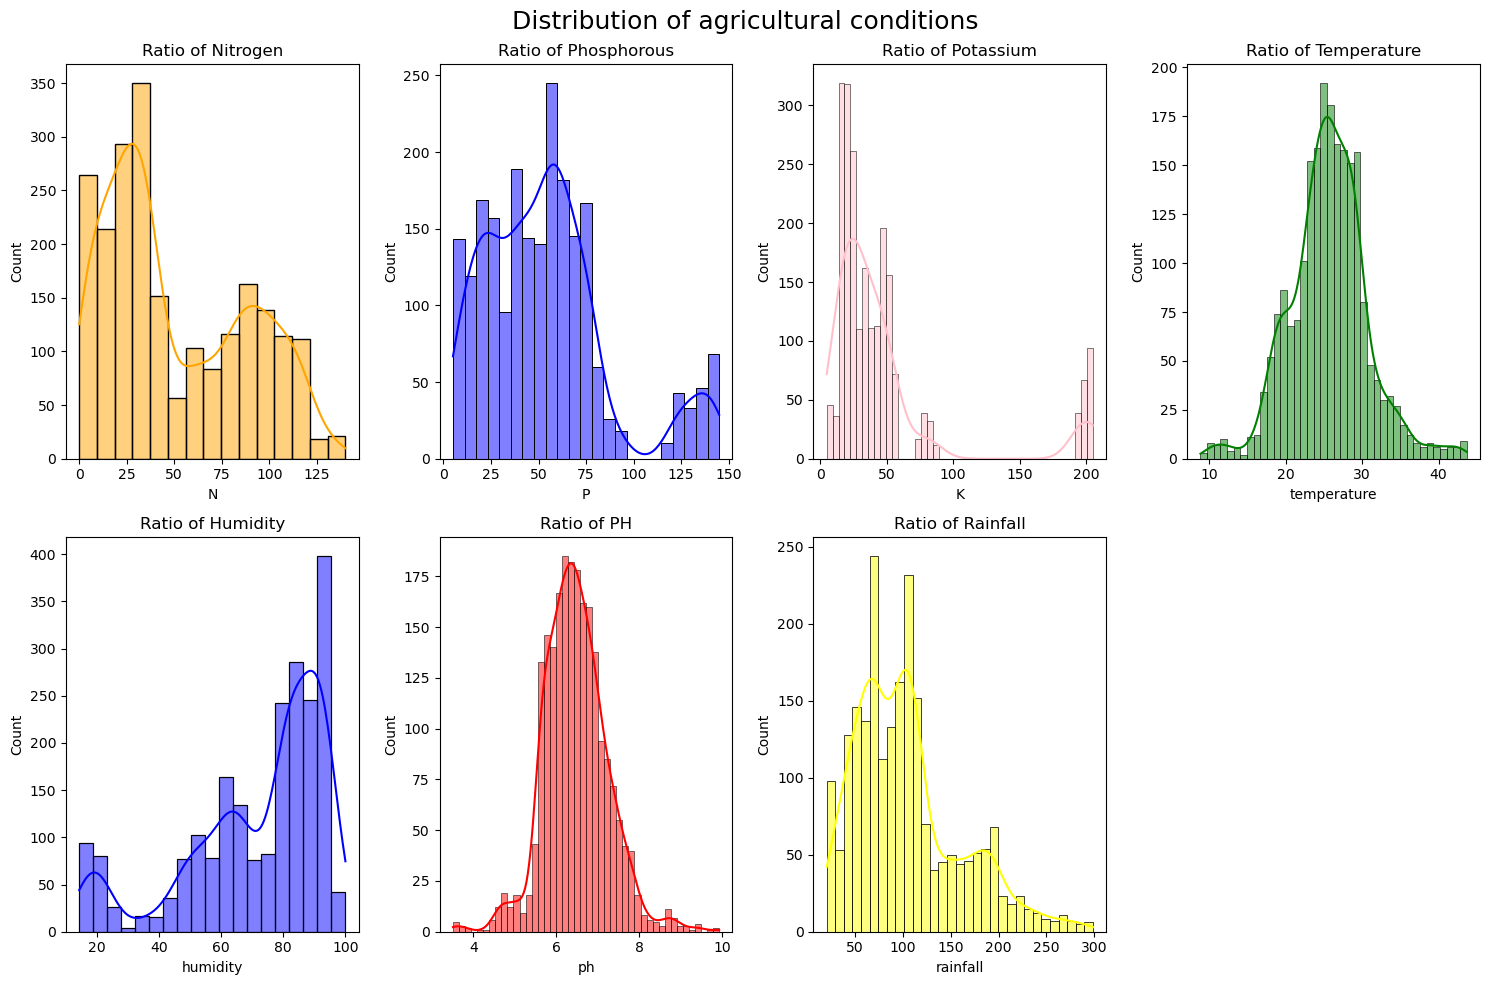

In [5]:
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = ['orange', 'blue', 'pink', 'green', 'blue', 'red', 'yellow']
titles = [
    'Ratio of Nitrogen',
    'Ratio of Phosphorous',
    'Ratio of Potassium',
    'Ratio of Temperature',
    'Ratio of Humidity',
    'Ratio of PH',
    'Ratio of Rainfall'
]
plt.figure(figsize=(15,10))

for i, col in enumerate(columns):
    plt.subplot(2,4,i+1)
    sns.histplot(data[col], kde=True, color=colors[i])
    plt.title(titles[i])

plt.suptitle("Distribution of agricultural conditions", fontsize=18)
plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

<Axes: >

<Axes: xlabel='humidity', ylabel='label'>

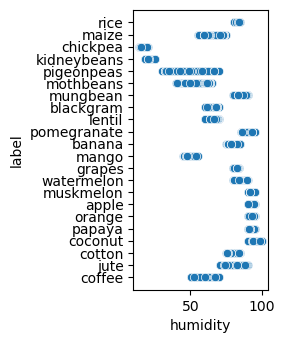

In [6]:
plt.figure(figsize=(8,8))

plt.subplot(2,4,7)
sns.scatterplot(x=data['humidity'], y=data['label'])

plt.show()

In [7]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [8]:
data = data.rename(columns={
    'N':'nitrogen',
    'P':'phosphorous',
    'K':'potassium'
})

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Feature', ylabel='count'>

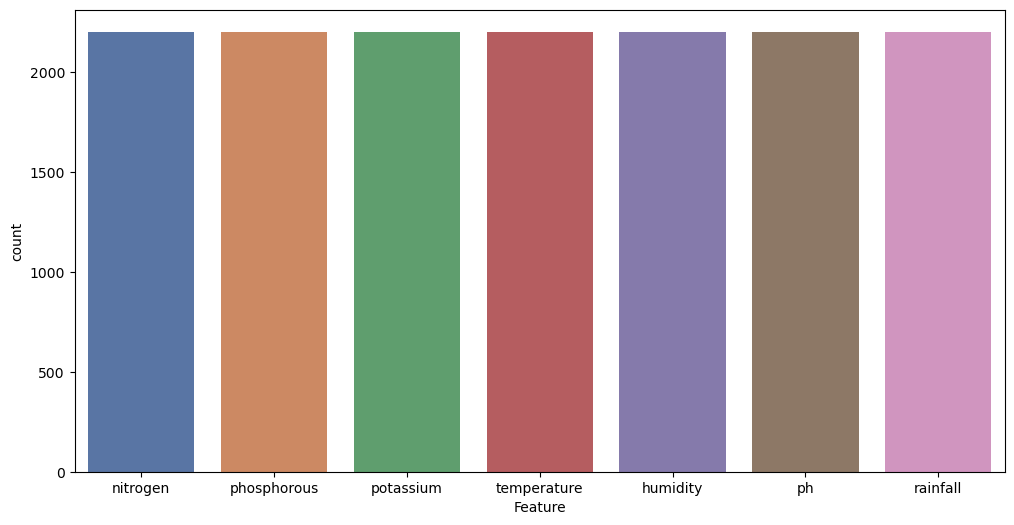

In [9]:
plot_df = data[['nitrogen','phosphorous','potassium','temperature','humidity','ph','rainfall']]

plot_df = plot_df.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(12,6))
sns.countplot(
    x='Feature',
    data=plot_df,
    hue='Feature',
    palette='deep',
    legend=False
)

plt.show()

In [10]:
data.describe()

,nitrogen,phosphorous,potassium,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
data.isnull().sum()

nitrogen       0
phosphorous    0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
data.shape

(2200, 8)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     2200 non-null   int64  
 1   phosphorous  2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


<Figure size 800x400 with 0 Axes>

<Axes: >

([<matplotlib.axis.XTick at 0x18773654050>,
 [Text(0, 0, 'nitrogen'),
  Text(1, 0, 'phosphorous'),
  Text(2, 0, 'potassium'),
  Text(3, 0, 'temperature'),
  Text(4, 0, 'humidity'),
  Text(5, 0, 'ph'),
  Text(6, 0, 'rainfall')])

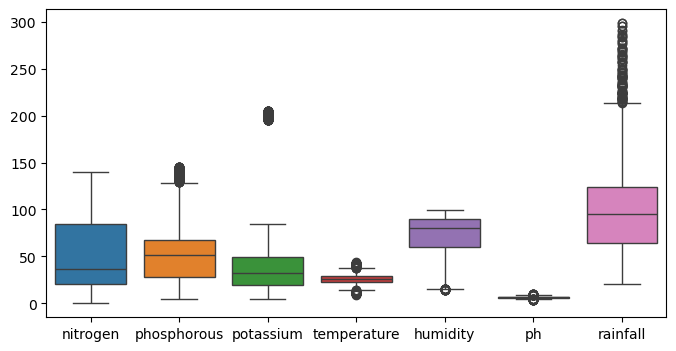

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(data=data[['nitrogen','phosphorous','potassium','temperature','humidity','ph','rainfall']])

plt.xticks(
    range(7),
    ['nitrogen','phosphorous','potassium','temperature','humidity','ph','rainfall']
)

plt.show()

In [15]:
Q1 = data['phosphorous'].quantile(0.25)
Q3 = data['phosphorous'].quantile(0.75)
IQR = Q3 - Q1

filter = (data['phosphorous'] >= Q1 - 1.5*IQR) & (data['phosphorous'] <= Q3 + 1.5*IQR)

data = data.loc[filter]


In [16]:
Q1 = data['potassium'].quantile(0.25)
Q3 = data['potassium'].quantile(0.75)
IQR = Q3 - Q1

filter = (data['potassium'] >= Q1 - 1.5*IQR) & (data['potassium'] <= Q3 + 1.5*IQR)

data = data.loc[filter]

In [17]:
Q1 = data['rainfall'].quantile(0.25)
Q3 = data['rainfall'].quantile(0.75)
IQR = Q3 - Q1

filter = (data['rainfall'] >= Q1 - 1.5*IQR) & (data['rainfall'] <= Q3 + 1.5*IQR)

data=data.loc[filter]

In [18]:
print("Summer crops")
print(data[(data['temperature'] > 30) & (data['humidity'] > 50)]['label'].unique())
print("----------------------------------------------")

print("Winter crops")
print(data[(data['temperature'] < 20) & (data['humidity'] > 30)]['label'].unique())
print("----------------------------------------------")

print("Rainy crops")
print(data[(data['rainfall'] > 200) & (data['humidity'] > 50)]['label'].unique())
print("----------------------------------------------")

Summer crops
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'orange' 'papaya']
----------------------------------------------
Winter crops
['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'orange']
----------------------------------------------
Rainy crops
['rice' 'papaya' 'coconut']
----------------------------------------------


In [19]:
y = data['label']
x = data.drop(['label'], axis=1)

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (1956, 7)
Shape of y: (1956,)


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=0
)

print("The shape of x_train:", x_train.shape)
print("The shape of x_test:", x_test.shape)
print("The shape of y_train:", y_train.shape)
print("The shape of y_test:", y_test.shape)

The shape of x_train: (1564, 7)
The shape of x_test: (392, 7)
The shape of y_train: (1564,)
The shape of y_test: (392,)


,n_clusters,1
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,7
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,9
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


Text(0.5, 1.0, 'The Elbow Method')

Text(0.5, 0, 'No of Clusters')

Text(0, 0.5, 'WCSS')

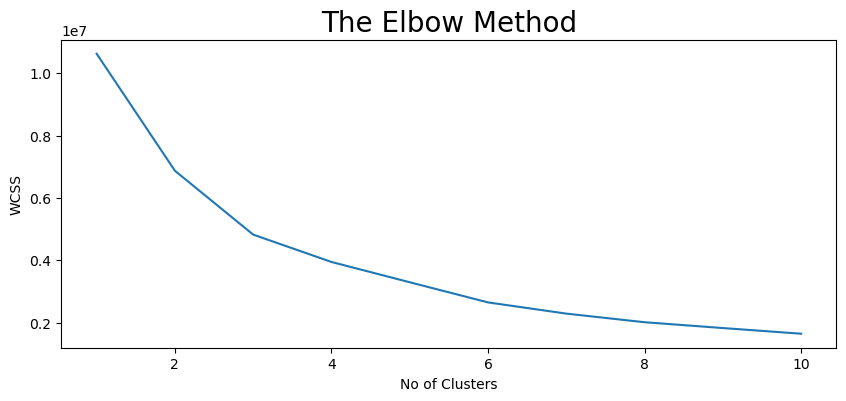

In [21]:
# Elbow method used to find out the optimum number of clusters

plt.rcParams['figure.figsize'] = (10,4)

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                max_iter=300,
                n_init=10,
                random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title("The Elbow Method", fontsize=20)
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
km = KMeans(n_clusters=4,
            init='k-means++',
            max_iter=300,
            n_init=10,
            random_state=0)

y_means = km.fit_predict(x)

a = data['label']

y_means = pd.DataFrame(y_means)

z = pd.concat([y_means, a], axis=1)

z = z.rename(columns={0:'cluster'})
print("lets check the results after applying the K-Means clustering analysis \n")

print("Crops in First Cluster:", z[z['cluster']==0]['label'].unique())

print("------------------------------------------------------------")

print("Crops in Second Cluster:", z[z['cluster']==1]['label'].unique())

print("------------------------------------------------------------")

print("Crops in Third Cluster:", z[z['cluster']==2]['label'].unique())
print("------------------------------------------------------------")

print("Crops in Fourth Cluster:", z[z['cluster']==3]['label'].unique())

lets check the results after applying the K-Means clustering analysis 

Crops in First Cluster: [nan 'rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'banana' 'muskmelon']
------------------------------------------------------------
Crops in Second Cluster: ['rice' nan 'maize' 'pomegranate' 'banana' 'mango' 'watermelon'
 'muskmelon' 'orange' 'papaya' 'coconut' 'cotton']
------------------------------------------------------------
Crops in Third Cluster: [nan 'rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'lentil'
 'pomegranate' 'banana' 'mango' 'watermelon' 'muskmelon' 'orange']
------------------------------------------------------------
Crops in Fourth Cluster: ['rice' nan 'kidneybeans' 'pigeonpeas' 'muskmelon' 'orange' 'papaya'
 'coconut' 'cotton']


In [23]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

c:\Users\manju\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
from sklearn.metrics import classification_report
cr=classification_report(y_pred,y_test)
print(cr)

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        23
   blackgram       0.75      0.80      0.77        15
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        13
      coffee       1.00      1.00      1.00        22
      cotton       0.95      1.00      0.97        19
        jute       0.72      0.76      0.74        17
 kidneybeans       1.00      1.00      1.00        19
      lentil       0.91      0.91      0.91        23
       maize       1.00      0.91      0.95        23
       mango       0.95      0.95      0.95        19
   mothbeans       0.96      0.89      0.93        28
    mungbean       0.89      1.00      0.94        16
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        20
      papaya       0.95      0.86      0.90        22
  pigeonpeas       1.00      1.00      1.00        19
 pomegranate       1.00    

In [25]:
prediction=model.predict((np.array([[105,35,40,25,64,7,160]])))
print("The suggested crop for given climate condition is:",prediction)

The suggested crop for given climate condition is: ['coffee']


c:\Users\manju\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [26]:
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(model,f)